In [6]:
import pandas as pd

df_train_from_scratch = pd.read_csv("results/loss_from_scratch.csv")
df_train_base_model = pd.read_csv("results/loss_base_model.csv")
df_train_finetuned = pd.read_csv("results/loss_finetuned.csv")

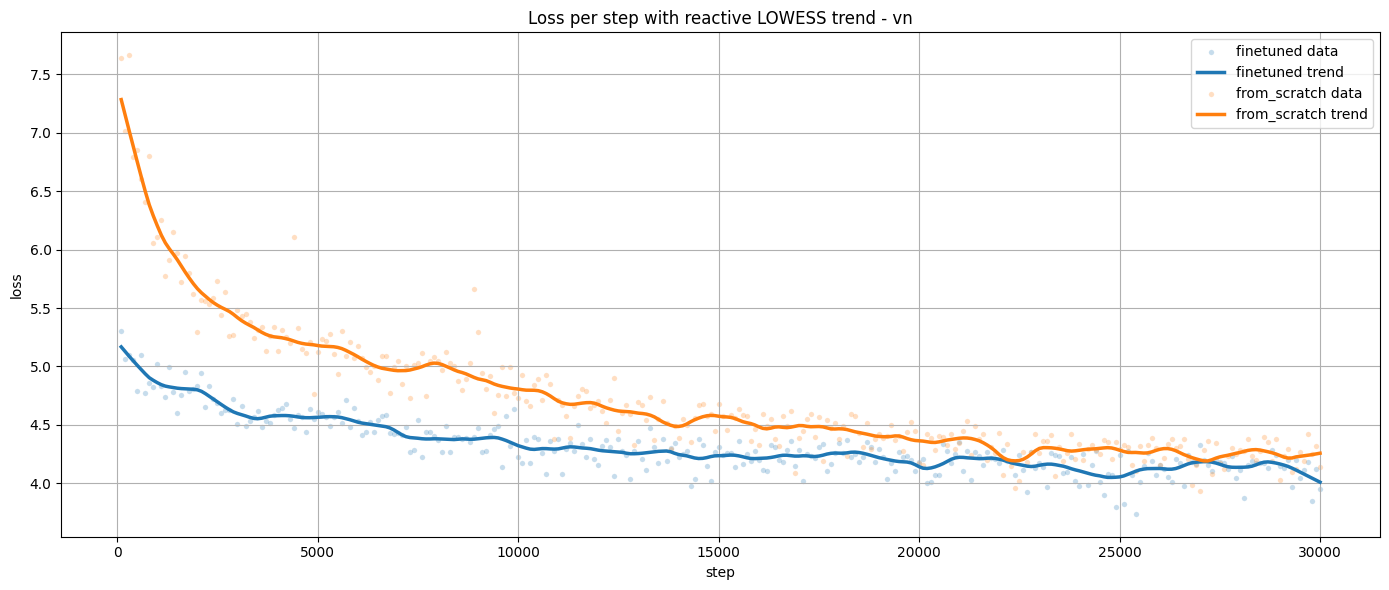

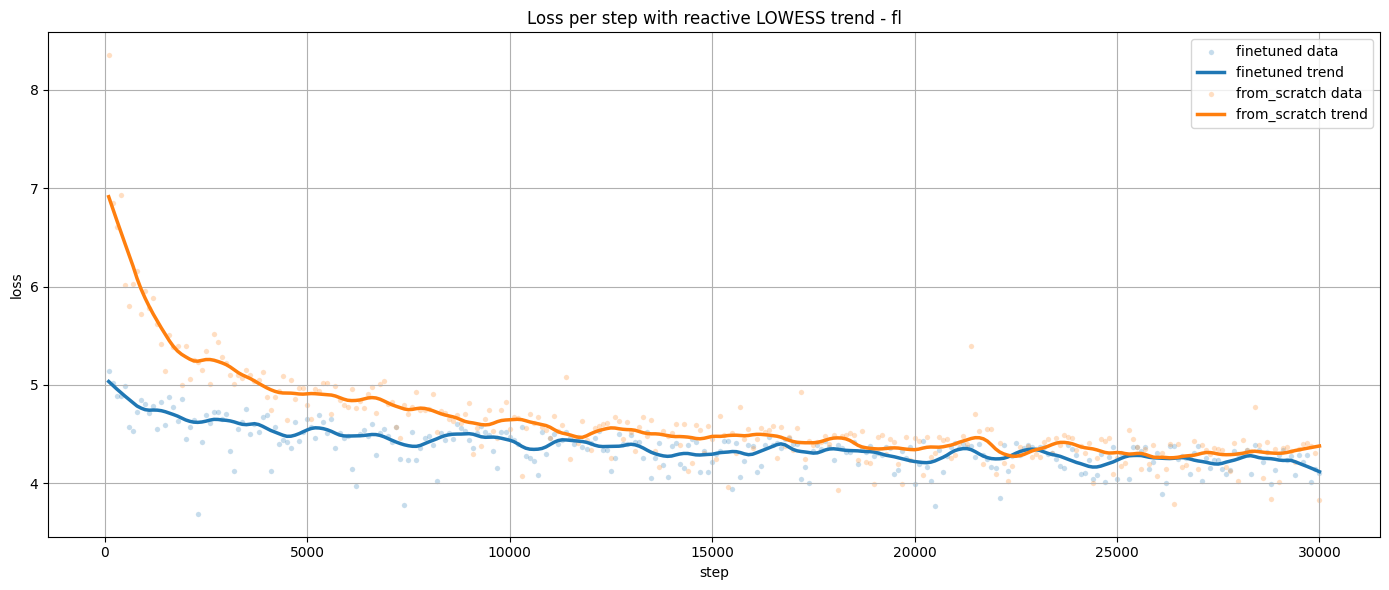

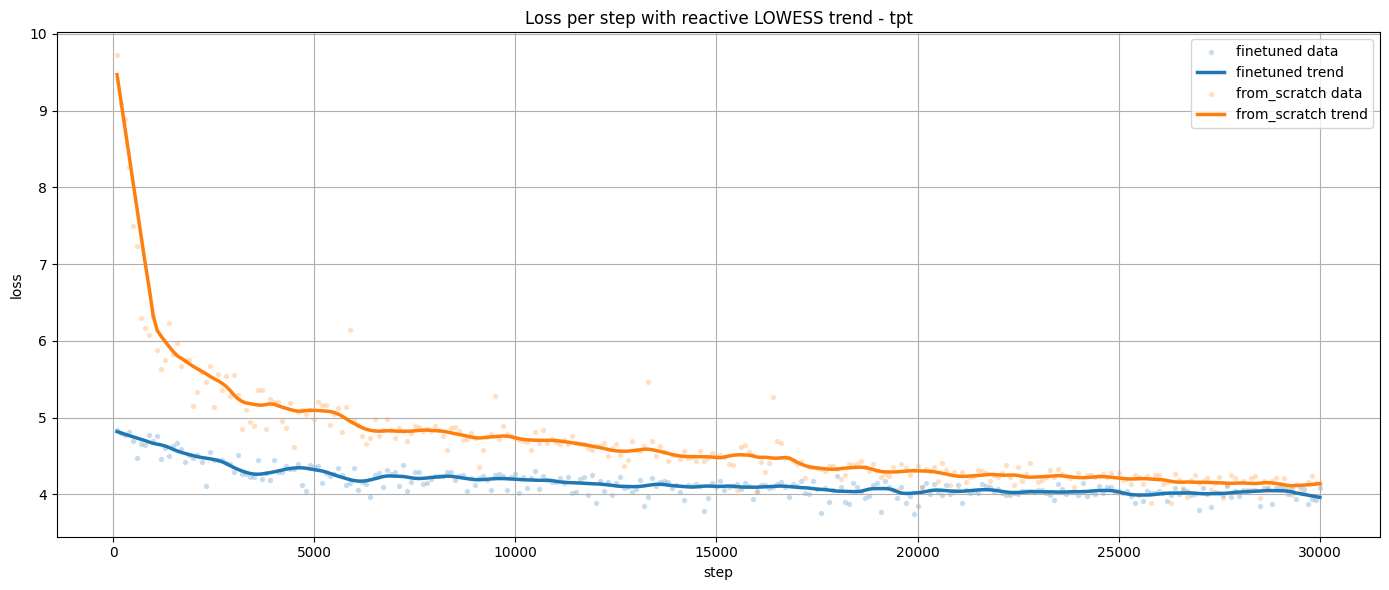

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# optional: clean whitespace in headers
for d in [df_train_from_scratch, df_train_finetuned, df_train_base_model]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch", df_train_from_scratch),
    ("finetuned", df_train_finetuned),
]

for instrument in instruments:
    rows = []

    for run_name, d in runs:
        if "Step" not in d.columns:
            continue

        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "series": run_name,
            }))

    if not rows:
        print(f"No valid loss columns found for {instrument}.")
        continue

    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    palette = sns.color_palette("tab10", n_colors=plot_df["series"].nunique())

    for color, (series_name, group) in zip(palette, plot_df.groupby("series")):
        group = group.sort_values("Step")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.25,
            s=15,
            label=f"{series_name} data",
        )

        y = group["loss"].to_numpy()

        # low-pass filter on uniform samples
        b, a = butter(N=3, Wn=0.05, btype="low")
        smoothed_y = filtfilt(b, a, y)

        ax.plot(group["Step"], smoothed_y, color=color, lw=2.5, label=f"{series_name} trend")

    ax.set_title(f"Loss per step with reactive LOWESS trend - {instrument}")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

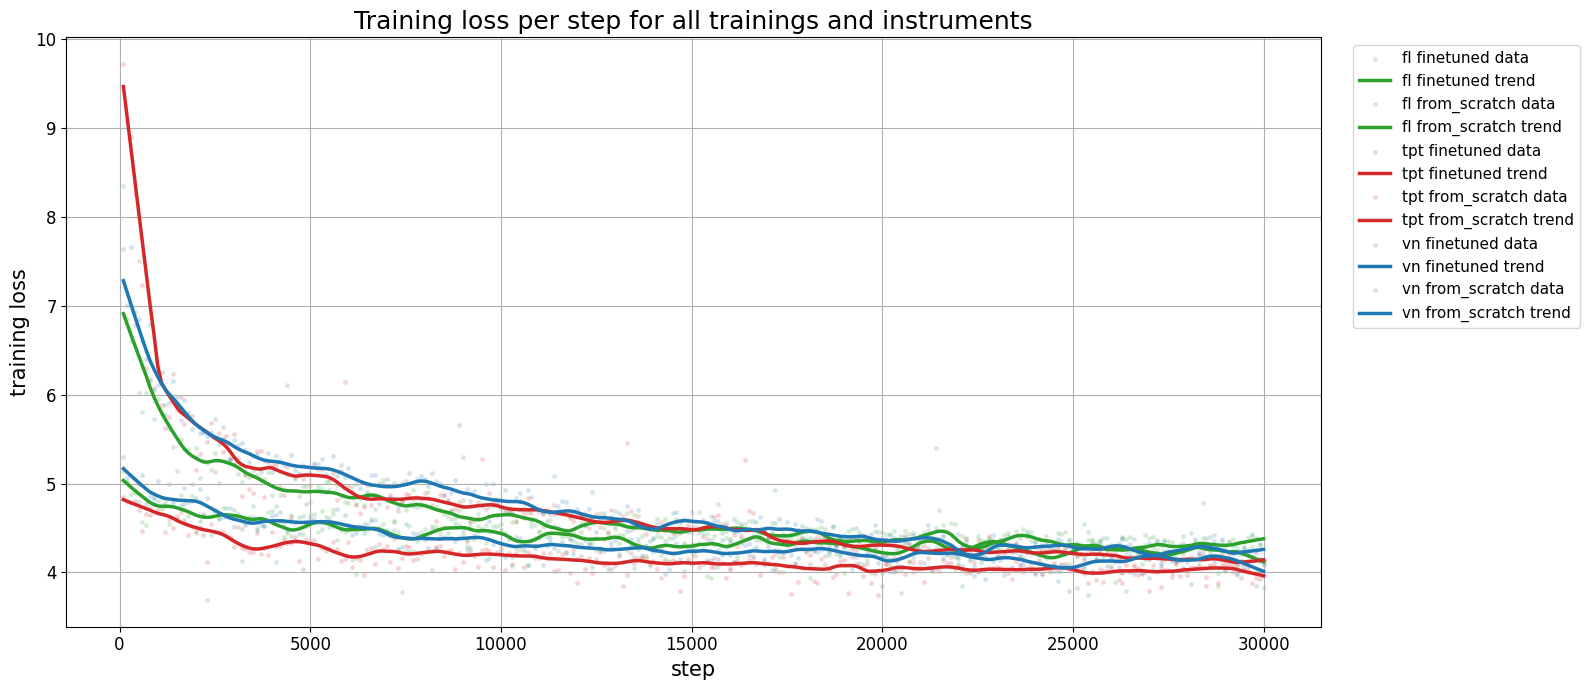

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# optional: clean whitespace in headers
for d in [df_train_from_scratch, df_train_finetuned, df_train_base_model]:
    d.columns = d.columns.str.strip()

instruments = ["vn", "fl", "tpt"]
runs = [
    ("from_scratch", df_train_from_scratch),
    ("finetuned", df_train_finetuned),
    ("base_model", df_train_base_model)
]

instrument_colors = {
    "vn": "#1f77b4",   # blue
    "fl": "#2ca02c",   # green
    "tpt": "#d62728",  # red
}

run_styles = {
    "from_scratch_fix": "-",
    "from_scratch_exp": "--",
    "from_scratch_tpt": ":",
    # "finetuned_exp": "-.",
}

rows = []
for run_name, d in runs:
    if "Step" not in d.columns:
        continue

    for instrument in instruments:
        col = f"{instrument} - loss"
        if col in d.columns:
            rows.append(pd.DataFrame({
                "Step": d["Step"],
                "loss": d[col],
                "instrument": instrument,
                "run": run_name,
                "series": f"{instrument} {run_name}",
            }))

if not rows:
    print("No valid training loss columns found.")
else:
    plot_df = pd.concat(rows, ignore_index=True).dropna()

    plt.figure(figsize=(16, 7))
    ax = plt.gca()

    for (instrument, run_name), group in plot_df.groupby(["instrument", "run"]):
        group = group.sort_values("Step")
        color = instrument_colors.get(instrument, "gray")
        linestyle = run_styles.get(run_name, "-")

        sns.scatterplot(
            data=group,
            x="Step",
            y="loss",
            ax=ax,
            color=color,
            alpha=0.20,
            s=12,
            label=f"{instrument} {run_name} data",
        )

        smoothed = lowess(
            endog=group["loss"],
            exog=group["Step"],
            frac=0.05,
            return_sorted=True
        )
        ax.plot(
            smoothed[:, 0],
            smoothed[:, 1],
            color=color,
            linestyle=linestyle,
            lw=2.5,
            label=f"{instrument} {run_name} trend"
        )

    ax.set_title("Training loss per step for all trainings and instruments", fontsize=18)
    ax.set_xlabel("step", fontsize=15)
    ax.set_ylabel("training loss", fontsize=15)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()